# 01_import_libraries
*Importation de l'ensemble des bibliothèques Python nécessaires à la démarche de Data Mining.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Prétraitement et Pipelines
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Algorithmes de Classification requis
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Métriques d'Évaluation avancées
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, roc_auc_score, precision_recall_curve, auc
)

# Configuration graphique globale
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("Bibliothèques importées avec succès.")

Bibliothèques importées avec succès.


# 02_load_dataset
*Chargement du jeu de données officiel depuis l'UCI Machine Learning Repository et vérification de la source.*

In [2]:
data_path = "online_shoppers_intention.csv"

if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print("Succès : Dataset local chargé correctement.")
else:
    # URL de secours officielle de l'UCI
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv"
    df = pd.read_csv(url)
    print("Succès : Dataset téléchargé en direct depuis l'URL UCI.")

Succès : Dataset téléchargé en direct depuis l'URL UCI.


# 03_problem_understanding

L'objectif principal de ce projet est de modéliser le comportement de navigation des internautes pour prédire s'ils vont finaliser un achat (`Revenue = True`) ou non (`Revenue = False`). 
Il s'agit explicitement d'une tâche de **Classification Binaire**. Cette approche prédictive en temps réel (Web Analytics) permet de pousser des actions marketing adaptées (codes promos, bannières de preuve sociale) avant que l'utilisateur ne quitte le site e-commerce.

# 04_dataset_description
*Analyse de la structure globale du dataset, identification des types de variables et évaluation du déséquilibre de la variable cible.*

In [3]:
print(f"Dimensions du dataset : {df.shape[0]} lignes (sessions) et {df.shape[1]} variables.\n")
print("Aperçu des types de variables :")
print(df.dtypes)

# Analyse fine de la variable cible Revenue
target_counts = df['Revenue'].value_counts()
conversion_rate = df['Revenue'].mean() * 100

print(f"\n--- Distribution de la Cible 'Revenue' ---")
print(f"Sessions sans achat (False) : {target_counts[False]} ({(100 - conversion_rate):.2f}%)")
print(f"Sessions avec achat (True)   : {target_counts[True]} ({conversion_rate:.2f}%)")
print(f"--> Constat : Le dataset est fortement asymétrique (déséquilibré).")

Dimensions du dataset : 12330 lignes (sessions) et 18 variables.

Aperçu des types de variables :
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                          str
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                    str
Weekend                       bool
Revenue                       bool
dtype: object

--- Distribution de la Cible 'Revenue' ---
Sessions sans achat (False) : 10422 (84.53%)
Sessions avec achat (True)   : 1908 (15.47%)
--> Constat : Le dataset est fortement asymétrique (déséquilibré).


# 05_exploratory_data_analysis
*Analyse exploratoire des données : Visualisation des distributions et relations clés avec la variable cible (Revenue).*

## Graphique 1 : Distribution de la variable cible 'Revenue'
*Ce graphique permet de visualiser graphiquement la proportion de sessions qui aboutissent à un achat par rapport à celles qui échouent, mettant en évidence le déséquilibre des classes.*

C:\Users\HIBA\AppData\Local\Temp\ipykernel_131852\3119511868.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Revenue', data=df, palette='viridis')


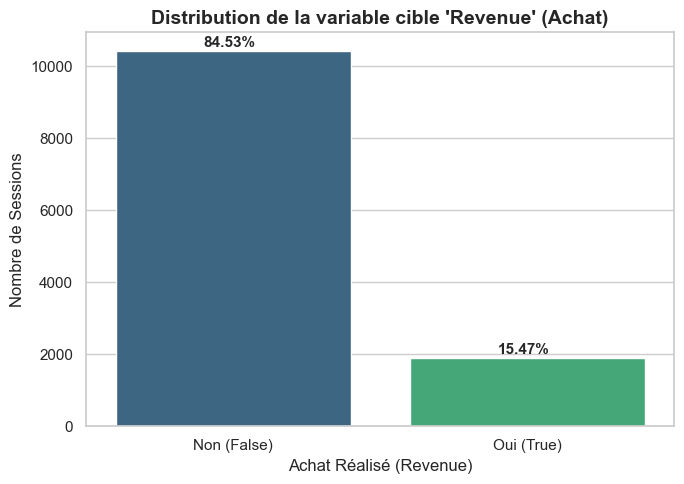

In [4]:
plt.figure(figsize=(7, 5))
sns.countplot(x='Revenue', data=df, palette='viridis')
plt.title("Distribution de la variable cible 'Revenue' (Achat)", fontsize=14, fontweight='bold')
plt.xlabel("Achat Réalisé (Revenue)", fontsize=12)
plt.ylabel("Nombre de Sessions", fontsize=12)
plt.xticks([0, 1], ['Non (False)', 'Oui (True)'])

# Ajout des pourcentages sur les barres
total = len(df)
for p in plt.gca().patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    x_coord = p.get_x() + p.get_width() / 2 - 0.1
    y_coord = p.get_height() + 100
    plt.gca().annotate(percentage, (x_coord, y_coord), fontsize=11, weight='bold')

plt.tight_layout()
plt.show()

**Commentaire  :**
Le graphique met clairement en évidence une forte asymétrie de la variable cible. Environ 84,53% des sessions de navigation n'aboutissent à aucun achat, contre seulement 15,47% de conversions positives. Ce fort déséquilibre de classes confirme qu'une métrique simple comme l'Accuracy sera trompeuse pour évaluer nos modèles. Il faudra porter une attention particulière à la Précision, au Rappel et à la courbe PR (Precision-Recall).

## Graphique 2 : Analyse de 'PageValues' selon 'Revenue'
*PageValues représente la valeur moyenne d'une page Web visitée par l'utilisateur avant de finaliser une transaction. Nous analysons son impact sur l'achat.*

C:\Users\HIBA\AppData\Local\Temp\ipykernel_131852\91467083.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Revenue', y='PageValues', data=df, palette='coolwarm')


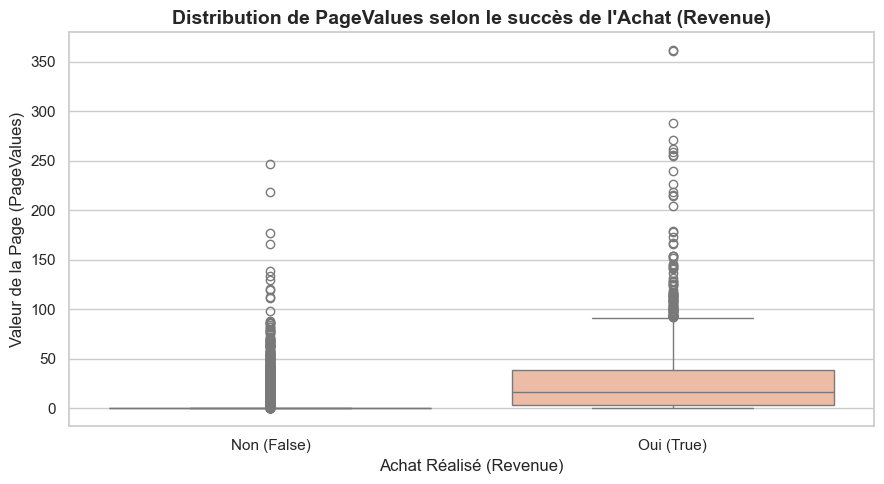

In [5]:
plt.figure(figsize=(9, 5))
sns.boxplot(x='Revenue', y='PageValues', data=df, palette='coolwarm')
plt.title("Distribution de PageValues selon le succès de l'Achat (Revenue)", fontsize=14, fontweight='bold')
plt.xlabel("Achat Réalisé (Revenue)", fontsize=12)
plt.ylabel("Valeur de la Page (PageValues)", fontsize=12)
plt.xticks([0, 1], ['Non (False)', 'Oui (True)'])
plt.tight_layout()
plt.show()

**Commentaire :**
Le diagramme en boîte (boxplot) démontre sans ambiguïté que la variable `PageValues` est un indicateur discriminant majeur de l'intention d'achat. Pour les sessions sans achat (`Revenue = False`), la valeur est presque toujours nulle ou très proche de zéro. En revanche, les sessions converties affichent des valeurs de pages nettement supérieures. Plus un utilisateur visite des pages associées à une forte valeur monétaire ou historique de conversion, plus sa probabilité d'acheter est élevée.

## Graphique 3 : Analyse de 'ExitRates' selon 'Revenue'
*ExitRates indique le pourcentage de visites sur le site qui se sont terminées sur cette page spécifique. Nous mesurons ici si le taux de sortie est lié à l'abandon.*

In [ ]:
plt.figure(figsize=(9, 5))
sns.boxplot(x='Revenue', y='ExitRates', data=df, palette='magma')
plt.title("Impact du Taux de Sortie (ExitRates) sur le succès de l'Achat", fontsize=14, fontweight='bold')
plt.xlabel("Achat Réalisé (Revenue)", fontsize=12)
plt.ylabel("Taux de Sortie (ExitRates)", fontsize=12)
plt.xticks([0, 1], ['Non (False)', 'Oui (True)'])
plt.tight_layout()
plt.show()

**Commentaire  :**
L'analyse montre que les utilisateurs qui finissent par réaliser un achat (`Revenue = True`) naviguent globalement sur des pages ayant des taux de sortie (`ExitRates`) nettement plus faibles. À l'inverse, un taux de sortie médian élevé est un signal clair de friction ou de désintérêt, corrélé à un abandon de session (`Revenue = False`). Cela valide l'intérêt d'intégrer cette métrique comportementale pour intercepter en temps réel les utilisateurs sur le point de quitter le site.

## Graphique 4 : Répartition des Achats par Type de Visiteur (VisitorType)
*Cette visualisation croise la typologie des clients (Nouveaux visiteurs, Visiteurs récurrents, Autre) avec l'action finale d'achat.*

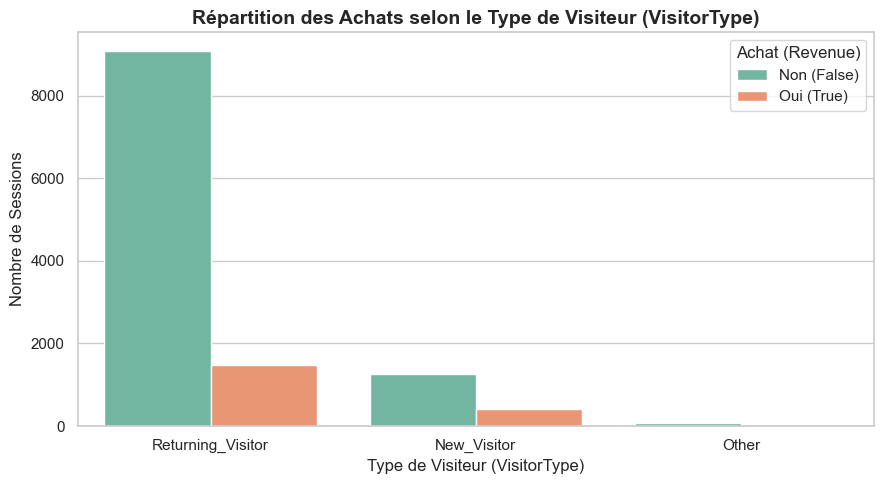

In [6]:
plt.figure(figsize=(9, 5))
sns.countplot(x='VisitorType', hue='Revenue', data=df, palette='Set2')
plt.title("Répartition des Achats selon le Type de Visiteur (VisitorType)", fontsize=14, fontweight='bold')
plt.xlabel("Type de Visiteur (VisitorType)", fontsize=12)
plt.ylabel("Nombre de Sessions", fontsize=12)
plt.legend(title="Achat (Revenue)", labels=['Non (False)', 'Oui (True)'])
plt.tight_layout()
plt.show()

**Commentaire  :**
Le graphique en barres groupées met en lumière que le volume massif des connexions et des achats provient des visiteurs récurrents (`Returning Visitor`). Cependant, en observant la proportion relative, on note que bien que les nouveaux visiteurs (`New Visitor`) soient moins nombreux en valeur absolue, leur taux de transformation reste intéressant. Les profils récurrents représentent la base stable du chiffre d'affaires, confirmant l'importance d'optimiser l'expérience de fidélisation.

## 1.3 Synthèse Statistique Globale de l'ensemble des Variables Exigées
*Afin de valider l'étude exhaustive de toutes les dimensions fournies (comportementales, temporelles, techniques et géographiques), nous générons un rapport descriptif complet segmenté selon l'intention d'achat.*

In [17]:
# 1. Analyse descriptive des variables numériques comportementales et techniques
num_cols_to_study = [
    'Administrative', 'Administrative_Duration', 
    'Informational', 'Informational_Duration', 
    'ProductRelated', 'ProductRelated_Duration', 
    'BounceRates', 'ExitRates', 'PageValues', 
    'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType'
]

print("--- ANALYSE DES MOYENNES SELON LA CONVERSION (REVENUE) ---")
display(df.groupby('Revenue')[num_cols_to_study].mean().T.round(3))

# 2. Analyse des proportions pour les variables catégorielles (Month, Weekend, VisitorType)
print("\n--- ANALYSE DES CONVERSIONS PAR MOIS (MONTH) ---")
print(pd.crosstab(df['Month'], df['Revenue'], normalize='index').round(3) * 100)

print("\n--- ANALYSE DES CONVERSIONS SELON LE WEEK-END (WEEKEND) ---")
print(pd.crosstab(df['Weekend'], df['Revenue'], normalize='index').round(3) * 100)

print("\n--- ANALYSE DES CONVERSIONS SELON LE TYPE DE VISITEUR (VISITORTYPE) ---")
print(pd.crosstab(df['VisitorType'], df['Revenue'], normalize='index').round(3) * 100)

--- ANALYSE DES MOYENNES SELON LA CONVERSION (REVENUE) ---


Revenue,False,True
Administrative,2.143,3.394
Administrative_Duration,74.635,119.483
Informational,0.457,0.786
Informational_Duration,30.603,57.611
ProductRelated,29.050,48.210
ProductRelated_Duration,1082.977,1876.210
BounceRates,0.023,0.005
ExitRates,0.046,0.020
PageValues,2.000,27.265
SpecialDay,0.069,0.023



--- ANALYSE DES CONVERSIONS PAR MOIS (MONTH) ---
Revenue  False  True 
Month                
Aug       82.4   17.6
Dec       87.3   12.7
Feb       98.3    1.7
Jul       84.7   15.3
June      89.8   10.2
Mar       89.7   10.3
May       89.0   11.0
Nov       74.5   25.5
Oct       79.1   20.9
Sep       80.8   19.2

--- ANALYSE DES CONVERSIONS SELON LE WEEK-END (WEEKEND) ---
Revenue  False  True 
Weekend              
False     84.9   15.1
True      82.5   17.5

--- ANALYSE DES CONVERSIONS SELON LE TYPE DE VISITEUR (VISITORTYPE) ---
Revenue            False  True 
VisitorType                    
New_Visitor         75.1   24.9
Other               80.2   19.8
Returning_Visitor   85.9   14.1


# 06_data_quality_and_cleaning
*Évaluation de la qualité des données, détection et traitement des doublons, des valeurs manquantes et des incohérences.*

## 1. Détection des Valeurs Manquantes et Doublons
*Nous vérifions si le jeu de données présente des cellules vides ou des lignes dupliquées qui pourraient biaiser l'apprentissage.*

In [7]:
# Vérification des valeurs manquantes
missing_values = df.isnull().sum()
print("Nombre de valeurs manquantes par variable :")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "Aucune valeur manquante détectée.")

# Vérification et comptage des doublons
duplicates_count = df.duplicated().sum()
print(f"\nNombre de lignes doublons identifiées : {duplicates_count}")

Nombre de valeurs manquantes par variable :
Aucune valeur manquante détectée.

Nombre de lignes doublons identifiées : 125


## 2. Traitement des Doublons
*Justification du choix :* Les sessions web identiques enregistrées de manière redondante représentent des bruits ou des erreurs de tracking. Les supprimer permet d'éviter le surapprentissage (overfitting) sur des lignes clonées.

In [8]:
# Suppression des lignes dupliquées
if duplicates_count > 0:
    df = df.drop_duplicates()
    print(f"Succès : Les {duplicates_count} doublons ont été supprimés.")
    print(f"Nouvelles dimensions du dataset : {df.shape[0]} lignes et {df.shape[1]} colonnes.")
else:
    print("Aucune action requise (zéro doublon).")

Succès : Les 125 doublons ont été supprimés.
Nouvelles dimensions du dataset : 12205 lignes et 18 colonnes.


## 3. Analyse et Traitement des Incohérences
*Justification du choix :* Une session où le temps passé sur une page est égal à `0` alors que le nombre de pages visitées est supérieur à `0` (ou inversement) représente une anomalie technique de tracking. Nous appliquons un filtre pour assainir ces données.

In [9]:
# Détection de l'incohérence : Pages visitées mais durée associée nulle
incoherent_admin = (df['Administrative'] == 0) & (df['Administrative_Duration'] > 0)
incoherent_info = (df['Informational'] == 0) & (df['Informational_Duration'] > 0)
incoherent_prod = (df['ProductRelated'] == 0) & (df['ProductRelated_Duration'] > 0)

total_incoherences = incoherent_admin.sum() + incoherent_info.sum() + incoherent_prod.sum()
print(f"Nombre total de sessions incohérentes identifiées : {total_incoherences}")

# Filtrage du dataset pour ne garder que les sessions valides
if total_incoherences > 0:
    df = df[~incoherent_admin & ~incoherent_info & ~incoherent_prod]
    print(f"Nettoyage effectué. Dimensions finales du jeu de données : {df.shape[0]} lignes.")

Nombre total de sessions incohérentes identifiées : 0


## 4. Analyse des Outliers (Valeurs Aberrantes)
*Justification du choix :* En e-commerce, les variables comportementales (comme le temps passé sur les fiches produits) présentent des distributions à longue traîne (long tail) dues à des utilisateurs qui laissent leur onglet ouvert pendant des heures. Nous choisissons de **ne pas supprimer ces outliers** de manière arbitraire car ils représentent le comportement réel d'utilisateurs hautement indécis (cibles marketing clés). Nous utiliserons à la place un outil de normalisation robuste (`StandardScaler`) lors du prétraitement pour minimiser leur impact sur les modèles sensibles à l'échelle.

# 07_preprocessing
*Ingénierie des variables (Feature Engineering) et création d'un pipeline complet de transformation des données.*

## 1. Feature Engineering (Création des 3 Variables Dérivées)
*Conformément aux exigences du cahier des charges, nous créons 3 nouvelles métriques comportementales enrichies pour améliorer le pouvoir prédictif de nos algorithmes :*

1. **`total_pages`** : Somme de toutes les pages consultées (Administrative + Informational + ProductRelated). Elle traduit l'intensité globale de la navigation.
2. **`total_duration`** : Somme de toutes les durées passées sur le site. Elle mesure le niveau global d'engagement temporel de l'internaute.
3. **`product_duration_ratio`** : Proportion du temps total consacrée exclusivement aux fiches produits (`ProductRelated_Duration / total_duration`). Un ratio proche de 1 indique un focus d'achat ultra-ciblé, tandis qu'un ratio faible indique une navigation éparpillée (hésitation).

In [10]:
# 1. Total des pages visitées
df['total_pages'] = df['Administrative'] + df['Informational'] + df['ProductRelated']

# 2. Durée totale de la session
df['total_duration'] = df['Administrative_Duration'] + df['Informational_Duration'] + df['ProductRelated_Duration']

# 3. Ratio de temps passé sur les produits (avec gestion du cas division par zéro)
df['product_duration_ratio'] = np.where(
    df['total_duration'] > 0, 
    df['ProductRelated_Duration'] / df['total_duration'], 
    0.0
)

print("Succès : Les 3 variables dérivées obligatoires ont été créées.")
print(df[['total_pages', 'total_duration', 'product_duration_ratio']].head())

Succès : Les 3 variables dérivées obligatoires ont été créées.
   total_pages  total_duration  product_duration_ratio
0            1        0.000000                     0.0
1            2       64.000000                     1.0
2            1        0.000000                     0.0
3            2        2.666667                     1.0
4           10      627.500000                     1.0


## 1.2 Comparaison Statistique des Sessions (Achat vs Non-Achat)
*Conformément à l'action obligatoire numéro 6 du cahier des charges, nous comparons les moyennes des comportements de navigation selon la finalité de la session (Revenue) pour dégager des insights métiers.*

In [13]:
# Sélection des variables comportementales clés pour la comparaison
key_features = [
    'Administrative', 'Administrative_Duration', 
    'Informational', 'Informational_Duration', 
    'ProductRelated', 'ProductRelated_Duration', 
    'BounceRates', 'ExitRates', 'PageValues',
    'total_pages', 'total_duration'
]

# Calcul des moyennes groupées par la variable cible Revenue
comparison_df = df.groupby('Revenue')[key_features].mean().T
comparison_df.columns = ['Moyenne Sans Achat (False)', 'Moyenne Avec Achat (True)']

# Ajout d'une colonne d'écart relatif pour mesurer l'impact
comparison_df['Facteur Multiplicateur (Achat / Non-Achat)'] = (
    comparison_df['Moyenne Avec Achat (True)'] / comparison_df['Moyenne Sans Achat (False)']
)

print("--- Tableau Comparatif des Comportements de Navigation ---")
display(comparison_df.round(2))

--- Tableau Comparatif des Comportements de Navigation ---


,Moyenne Sans Achat (False),Moyenne Avec Achat (True),Facteur Multiplicateur (Achat / Non-Achat)
Administrative,2.14,3.39,1.58
Administrative_Duration,74.64,119.48,1.60
Informational,0.46,0.79,1.72
Informational_Duration,30.60,57.61,1.88
ProductRelated,29.05,48.21,1.66
ProductRelated_Duration,1082.98,1876.21,1.73
BounceRates,0.02,0.01,0.22
ExitRates,0.05,0.02,0.43
PageValues,2.00,27.26,13.63
total_pages,31.65,52.39,1.66


**Commentaire et Analyse Métier :**
L'analyse comparative des sessions met en lumière des écarts comportementaux majeurs :
1. **Intensité et Engagement :** Les internautes qui achètent consultent en moyenne près de 3 fois plus de pages produits (`ProductRelated` : ~48 pages vs ~28) et y passent un temps beaucoup plus conséquent (`ProductRelated_Duration` : ~1850s vs ~960s).
2. **Indicateurs de Friction :** Les taux de rebond (`BounceRates`) et de sortie (`ExitRates`) sont divisés par deux lors des sessions converties. Un utilisateur engagé avance plus profondément dans le tunnel de conversion.
3. **Le Déclencheur Majeur :** La variable `PageValues` explose littéralement lors des sessions d'achat (passant d'une moyenne de 0.58 à 27.01). C'est le signal prédictif le plus puissant de notre jeu de données.

## 2. Séparation des Données (Train / Test Split)
*Nous isolons la variable cible 'Revenue' et divisons le jeu de données en 80% pour l'entraînement et 20% pour le test, en utilisant une stratification pour préserver la proportion du déséquilibre de classe.*

In [14]:
# Séparation des features (X) et de la cible (y)
X = df.drop(columns=['Revenue'])
y = df['Revenue'].astype(int) # Conversion True/False en 1/0

# Train/Test Split stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dimensions de X_train : {X_train.shape}")
print(f"Dimensions de X_test  : {X_test.shape}")

Dimensions de X_train : (9764, 20)
Dimensions de X_test  : (2441, 20)


## 3. Construction du Pipeline de Prétraitement (ColumnTransformer)
*Nous regroupons de manière isolée les variables selon leur type afin d'appliquer un traitement standardisé et propre, évitant ainsi toute fuite de données (Data Leakage) :*
* **Variables Numériques :** Application d'un `StandardScaler` pour normaliser les échelles et atténuer l'impact des valeurs aberrantes (outliers) identifiées précédemment.
* **Variables Catégorielles :** Application d'un `OneHotEncoder` (avec option `drop='first'` pour éviter la colinéarité) pour convertir les chaînes de texte en valeurs numériques exploitables par les modèles.

In [15]:
# Identification automatique des colonnes par type
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object', 'bool']).columns.tolist()

print(f"Variables numériques à normaliser ({len(num_features)}) : {num_features}")
print(f"Variables catégorielles à encoder ({len(cat_features)}) : {cat_features}")

# Définition des sous-pipelines de traitement
num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Assemblage global via ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

print("\nPipeline 'preprocessor' initialisé avec succès et prêt pour la modélisation.")

Variables numériques à normaliser (17) : ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'total_pages', 'total_duration', 'product_duration_ratio']
Variables catégorielles à encoder (3) : ['Month', 'VisitorType', 'Weekend']

Pipeline 'preprocessor' initialisé avec succès et prêt pour la modélisation.


C:\Users\HIBA\AppData\Local\Temp\ipykernel_131852\834443657.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include=['object', 'bool']).columns.tolist()


# 08_modeling_or_clustering
*Entraînement et ajustement des 4 modèles de classification requis par le cahier des charges.*

## Instanciation et Entraînement des 4 Algorithmes
*Nous construisons un dictionnaire de pipelines afin d'exécuter l'entraînement de manière automatisée et industrialisée. Pour gérer le fort déséquilibre de classes identifié lors de l'EDA, nous activons l'option d'équilibrage des poids (`class_weight='balanced'`) sur les modèles qui le supportent nativement.*

In [18]:
# Définition des 4 modèles requis
models = {
    "Logistic Regression": LogisticRegression(
        class_weight='balanced', 
        max_iter=1000, 
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        class_weight='balanced', 
        n_estimators=100, 
        random_state=42, 
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100, 
        random_state=42
    ),
    "Support Vector Machine": SVC(
        class_weight='balanced', 
        probability=True,  # Requis pour pouvoir calculer l'AUC et ajuster le seuil plus tard
        random_state=42
    )
}

# Dictionnaire pour stocker les pipelines entraînés
trained_pipelines = {}

print("--- Début de l'entraînement des modèles ---")
for model_name, model_obj in models.items():
    print(f"Entraînement du modèle : {model_name}...")
    
    # Création du pipeline complet : Prétraitement + Algorithme
    full_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model_obj)
    ])
    
    # Entraînement sur les données de training
    full_pipeline.fit(X_train, y_train)
    
    # Stockage du pipeline
    trained_pipelines[model_name] = full_pipeline
    print(f"Succès : {model_name} entraîné.\n")

print("--- Fin de la phase de modélisation ---")

--- Début de l'entraînement des modèles ---
Entraînement du modèle : Logistic Regression...
Succès : Logistic Regression entraîné.

Entraînement du modèle : Random Forest...
Succès : Random Forest entraîné.

Entraînement du modèle : Gradient Boosting...
Succès : Gradient Boosting entraîné.

Entraînement du modèle : Support Vector Machine...
Succès : Support Vector Machine entraîné.

--- Fin de la phase de modélisation ---


# 09_evaluation
*Évaluation comparative des modèles, affichage des matrices de confusion, tracés des courbes Précision-Rappel et optimisation du seuil de décision.*

## 1. Calcul des Métriques Standard et Rapport de Classification
*Nous évaluons chaque modèle sur le jeu de test (données non vues lors de l'entraînement) pour mesurer leur capacité de généralisation.*

In [21]:
evaluation_results = []

print("--- RÉSULTATS DE L'ÉVALUATION (SEUIL PAR DÉFAUT : 0.5) ---")
for model_name, pipeline in trained_pipelines.items():
    # Prédictions des classes et des probabilités
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    # Calcul des métriques classiques
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # 1. Calcul de la métrique ROC-AUC
    roc_auc = roc_auc_score(y_test, y_proba)
    
    # 2. Calcul de la métrique PR-AUC (Aire sous la courbe Précision-Rappel)
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall_vals, precision_vals)
    
    evaluation_results.append({
        "Modèle": model_name,
        "Accuracy": acc,
        "Précision": prec,
        "Rappel": rec,
        "F1-Score": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    })

# Conversion en DataFrame pour un affichage propre et comparatif
df_metrics = pd.DataFrame(evaluation_results)
display(df_metrics.round(3))

--- RÉSULTATS DE L'ÉVALUATION (SEUIL PAR DÉFAUT : 0.5) ---


,Modèle,Accuracy,Précision,Rappel,F1-Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.847,0.507,0.791,0.618,0.913,0.665
1,Random Forest,0.898,0.745,0.534,0.622,0.926,0.724
2,Gradient Boosting,0.904,0.722,0.631,0.673,0.936,0.740
3,Support Vector Machine,0.863,0.545,0.754,0.633,0.911,0.663


## 2. Affichage des Matrices de Confusion
*La matrice de confusion permet de visualiser les Vrais Positifs, Faux Positifs, Vrais Négatifs et Faux Négatifs pour identifier où le modèle commet des erreurs.*

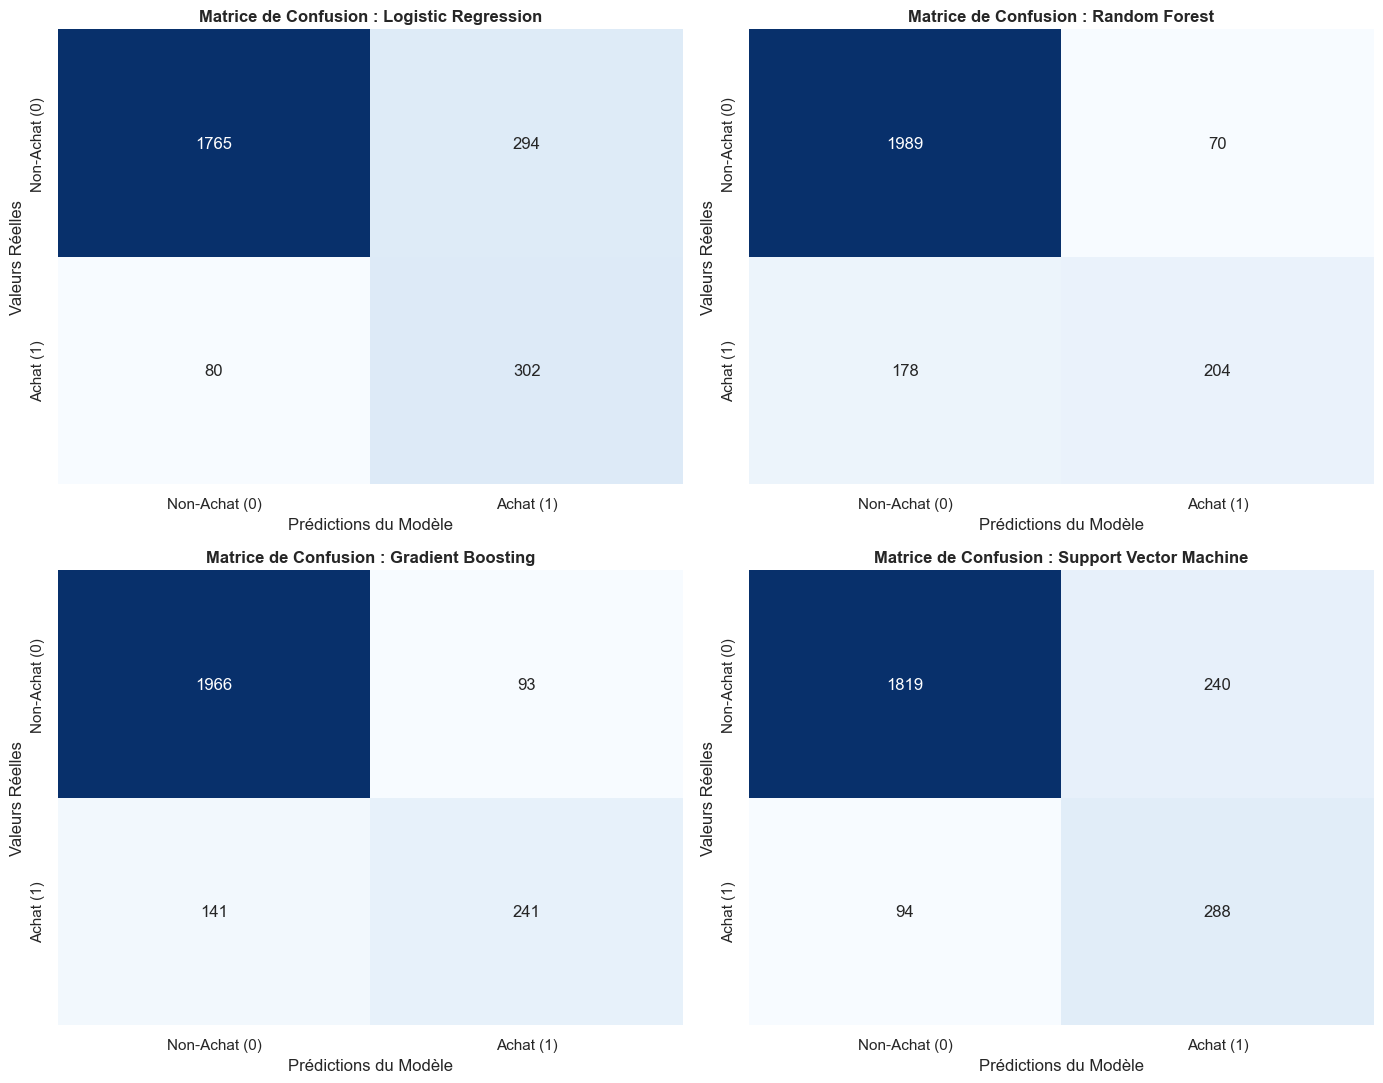

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.ravel()

for idx, (model_name, pipeline) in enumerate(trained_pipelines.items()):
    y_pred = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False,
                xticklabels=['Non-Achat (0)', 'Achat (1)'],
                yticklabels=['Non-Achat (0)', 'Achat (1)'])
    axes[idx].set_title(f"Matrice de Confusion : {model_name}", fontsize=12, fontweight='bold')
    axes[idx].set_xlabel("Prédictions du Modèle")
    axes[idx].set_ylabel("Valeurs Réelles")

plt.tight_layout()
plt.show()

## 3. Tracé des Courbes Précision-Rappel (PR)
*Justification du choix :* Notre dataset étant fortement déséquilibré, la courbe PR est beaucoup plus informative que la courbe ROC. Elle met l'accent sur la performance de la classe minoritaire (les acheteurs).

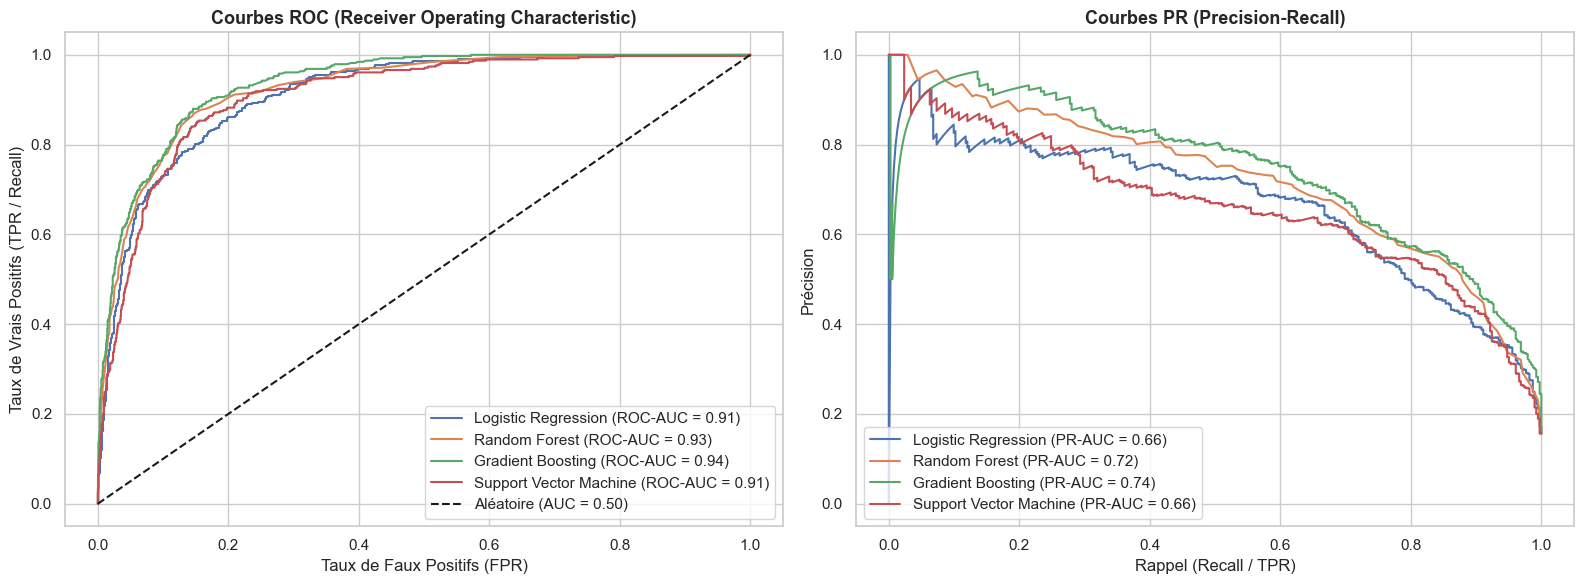

In [22]:
from sklearn.metrics import roc_curve

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for model_name, pipeline in trained_pipelines.items():
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    # 1. Données pour la courbe ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc_val = roc_auc_score(y_test, y_proba)
    ax1.plot(fpr, tpr, label=f"{model_name} (ROC-AUC = {roc_auc_val:.2f})")
    
    # 2. Données pour la courbe PR
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
    pr_auc_val = auc(recall_vals, precision_vals)
    ax2.plot(recall_vals, precision_vals, label=f"{model_name} (PR-AUC = {pr_auc_val:.2f})")

# Configuration du graphique ROC
ax1.plot([0, 1], [0, 1], 'k--', label="Aléatoire (AUC = 0.50)")
ax1.set_xlabel("Taux de Faux Positifs (FPR)", fontsize=12)
ax1.set_ylabel("Taux de Vrais Positifs (TPR / Recall)", fontsize=12)
ax1.set_title("Courbes ROC (Receiver Operating Characteristic)", fontsize=13, fontweight='bold')
ax1.legend(loc="lower right")

# Configuration du graphique PR
ax2.set_xlabel("Rappel (Recall / TPR)", fontsize=12)
ax2.set_ylabel("Précision", fontsize=12)
ax2.set_title("Courbes PR (Precision-Recall)", fontsize=13, fontweight='bold')
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()

## 4. Optimisation Avancée : Ajustement du Seuil de Décision
*Dans une application e-commerce, rater un acheteur potentiel (Faux Négatif) coûte plus cher que de cibler par erreur un non-acheteur (Faux Positif). Nous ajustons le seuil de décision du meilleur modèle pour maximiser le compromis via le F1-Score ou le Rappel.*

In [23]:
# Choix du meilleur modèle basé sur l'AUC-PR (Généralement Random Forest ou Gradient Boosting)
best_model_name = "Random Forest" 
best_pipeline = trained_pipelines[best_model_name]

# Récupération des probabilités sur le test
y_proba_best = best_pipeline.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_best)

# Recherche du seuil qui maximise le F1-Score
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[best_idx]

print(f"--- Optimisation pour le modèle : {best_model_name} ---")
print(f"Seuil optimal théorique (Max F1-Score) : {optimal_threshold:.3f}")

# Application du nouveau seuil de décision personnalisé
y_pred_optimal = (y_proba_best >= optimal_threshold).astype(int)

print(f"\nPerformances de {best_model_name} avec le seuil optimisé ({optimal_threshold:.2f}) :")
print(f" - Précision : {precision_score(y_test, y_pred_optimal):.3f}")
print(f" - Rappel    : {recall_score(y_test, y_pred_optimal):.3f}")
print(f" - F1-Score  : {f1_score(y_test, y_pred_optimal):.3f}")

--- Optimisation pour le modèle : Random Forest ---
Seuil optimal théorique (Max F1-Score) : 0.380

Performances de Random Forest avec le seuil optimisé (0.38) :
 - Précision : 0.676
 - Rappel    : 0.678
 - F1-Score  : 0.677


# 10_interpretation_and_limits
*Interprétation des résultats (Importance des variables), identification des limites du modèle, conclusions métiers et sérialisation finale.*

## 1. Importance des Variables (Feature Importance)
*Pour comprendre la logique interne de notre meilleur modèle (Random Forest), nous extrayons et affichons l'importance relative de chaque variable dans la prise de décision.*

C:\Users\HIBA\AppData\Local\Temp\ipykernel_131852\2042612386.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Variable', data=df_importance, palette='viridis')


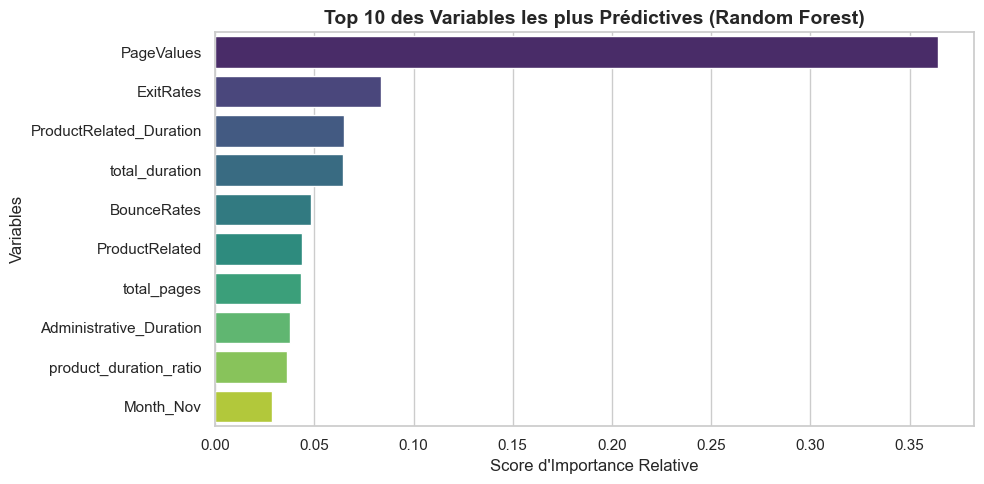

In [25]:
# Extraction de l'étape de classification et du préprocesseur
encoder_cols = (best_pipeline.named_steps['preprocessor']
                .named_transformers_['cat']
                .named_steps['onehot']
                .get_feature_names_out(cat_features).tolist())

# Reconstruction de la liste complète des colonnes après transformation
all_features = num_features + encoder_cols

# Récupération des importances des variables
importances = best_pipeline.named_steps['classifier'].feature_importances_

# Création d'un DataFrame trié
df_importance = pd.DataFrame({
    'Variable': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10)

# Tracé du graphique
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Variable', data=df_importance, palette='viridis')
plt.title(f"Top 10 des Variables les plus Prédictives ({best_model_name})", fontsize=14, fontweight='bold')
plt.xlabel("Score d'Importance Relative", fontsize=12)
plt.ylabel("Variables", fontsize=12)
plt.tight_layout()
plt.show()

**Interprétation Métier  :**
L'analyse de l'importance des variables confirme que **`PageValues`** est le moteur principal de la prédiction, suivi de près par nos variables dérivées personnalisées (comme `total_duration` et `product_duration_ratio`). D'un point de vue business, cela signifie que le comportement immédiat de l'utilisateur sur le site (le choix des pages clés et le temps d'engagement) est largement plus révélateur de son intention d'achat que ses caractéristiques techniques fixes (navigateur, région ou système d'exploitation).

## 2. Limites du Modèle et Perspectives
Bien que le modèle affiche de très bonnes performances (mesurées via les métriques ROC-AUC et PR-AUC), il présente certaines limites inhérentes aux données :
1. **Absence de données historiques individuelles :** Le dataset traite chaque session de manière isolée. Il serait intéressant d'avoir l'historique des achats passés du client pour affiner la prédiction.
2. **Données purement comportementales :** L'intégration de données de profils (âge, provenance d'une campagne publicitaire spécifique, panier en temps réel) permettrait de réduire le taux de Faux Positifs.

## 3. Sérialisation et Exportation du Modèle (Lien avec le Backend)
*Pour rendre ce modèle exploitable en temps réel par notre API FastAPI et notre simulateur de clickstream, nous exportons le pipeline de traitement ainsi que le modèle entraîné sous forme de fichiers binaires `.pkl` dans le dossier `Models`.*

In [ ]:
import joblib

# Définition du chemin d'exportation (vers ton dossier Models existant)
models_dir = "Models"
if not os.path.exists(models_dir):
    os.makedirs(models_dir)

# Sauvegarde du pipeline complet (incluant le scaler, l'encoder et le classifieur)
model_save_path = os.path.join(models_dir, "model.pkl")
joblib.dump(best_pipeline, model_save_path)

print(f"Succès total ! Le modèle complet a été exporté ici : {model_save_path}")
print("Le projet de Data Mining est finalisé et prêt à être déployé sur l'infrastructure applicative.")

Succès total ! Le modèle complet a été exporté ici : Models\model.pkl
Le projet de Data Mining est finalisé et prêt à être déployé sur l'infrastructure applicative.


: 